# 1. Install and import libraries

In [89]:
# 1. install dependencies

!pip install -q ultralytics

# 2. import libraries

import os
import yaml
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import torch
import hashlib
import shutil
from collections import Counter
import requests
from PIL import Image
from io import BytesIO

# 2. Check GPU

In [2]:
print("Torch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Torch Version: 2.10.0+cu128
GPU Available: True
GPU Name: Tesla T4


# 3. List folders

In [3]:
os.listdir('/kaggle/input/datasets/natashashrestha7/fingredient')

['README.dataset.txt',
 'README.roboflow.txt',
 'data.yaml',
 'valid',
 'test',
 'train']

# 4. Set dataset path

In [8]:
DATASET_PATH = "/kaggle/input/datasets/natashashrestha7/fingredient"
YAML_PATH = DATASET_PATH + "/data.yaml"

# 5. Read YAML file

In [5]:
with open(YAML_PATH, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 20, 'names': ['beef', 'bell_pepper', 'cabbage', 'carrot', 'cauliflower', 'chicken', 'cucumber', 'egg', 'fish', 'garlic', 'ginger', 'kumquat', 'lemon', 'onion', 'pork', 'potato', 'shrimp', 'small_pepper', 'tofu', 'tomato'], 'roboflow': {'workspace': 'my-workspace-idgwe', 'project': 'food-ingredients-2alny', 'version': 5, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/my-workspace-idgwe/food-ingredients-2alny/dataset/5'}}


# 6. Count total images

In [6]:
def count_images(folder):
    return len(list(Path(folder).glob("*.*")))

print("Train:", count_images(DATASET_PATH + "/train/images"))
print("Valid:", count_images(DATASET_PATH + "/valid/images"))
print("Test :", count_images(DATASET_PATH + "/test/images"))

Train: 13000
Valid: 2500
Test : 2173


# 7. Visualise training images

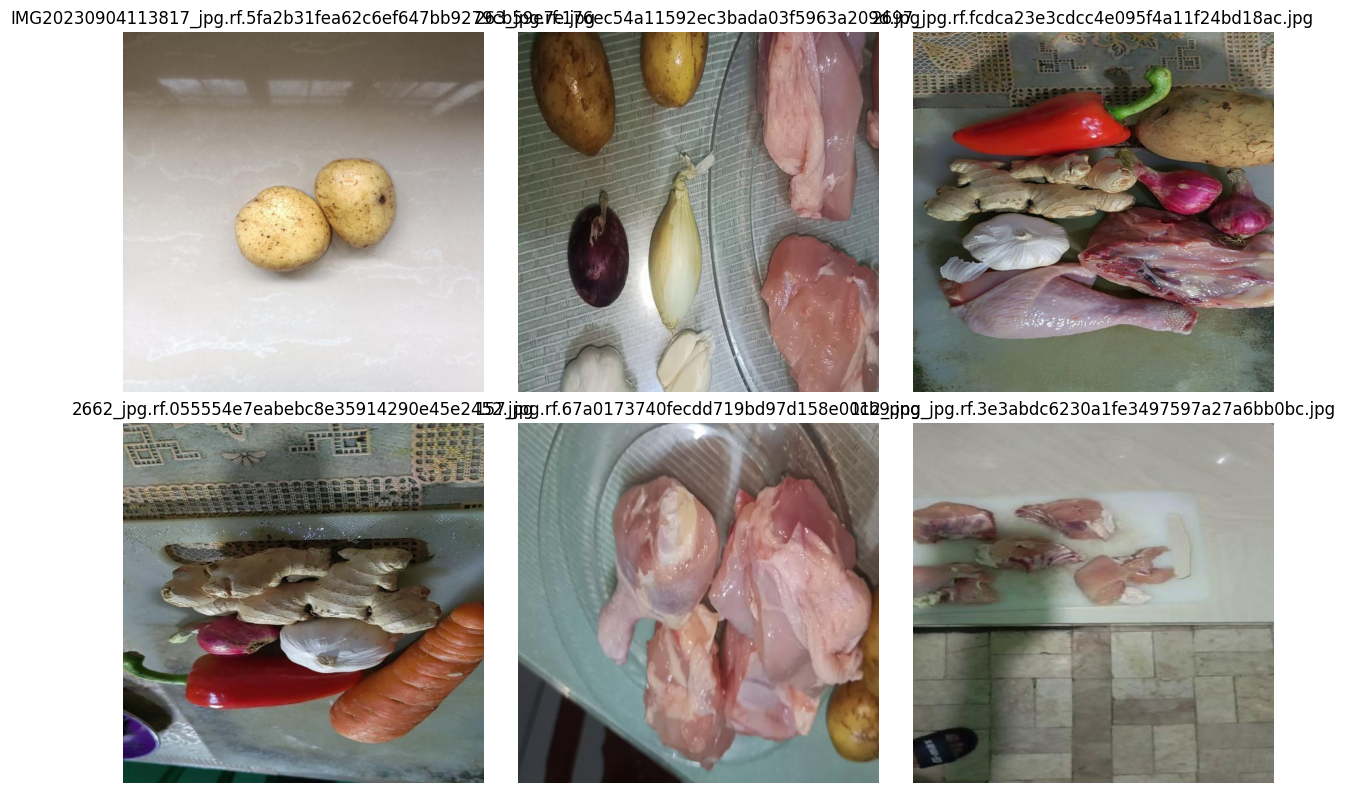

In [7]:
train_imgs = list(Path(DATASET_PATH + "/train/images").glob("*.*"))

plt.figure(figsize=(12,8))

for i in range(6):
    img_path = random.choice(train_imgs)
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 7. Check corrupted images

In [8]:
from PIL import Image
import os

folder = "/kaggle/input/datasets/natashashrestha7/fingredient/train/images"

for file in os.listdir(folder):
    path = os.path.join(folder, file)
    try:
        img = Image.open(path)
        img.verify()
    except:
        print("Corrupted:", file)

# 8. Set training image and label path

In [9]:
TRAIN_IMG = DATASET_PATH + "/train/images"
TRAIN_LABEL = DATASET_PATH + "/train/labels"

# 9. Check duplicate images

In [10]:
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for file in os.listdir(TRAIN_IMG):
    path = os.path.join(TRAIN_IMG, file)
    
    h = file_hash(path)

    if h in hashes:
        duplicates.append((file, hashes[h]))
    else:
        hashes[h] = file

print("Total Duplicate Images Found:", len(duplicates))
print()

for dup in duplicates[:20]:
    print("Duplicate:", dup[0], "==", dup[1])

Total Duplicate Images Found: 143

Duplicate: 493_jpg.rf.50e9c286d4c301835eff3e54d934ec7c.jpg == 493_jpg.rf.ebf8714ea2674369fef43d2a52b604bb.jpg
Duplicate: 1038_jpg.rf.143e152fa81ca57e74a6b90992a23cdf.jpg == 1038_jpg.rf.2c4775991c2fc168668ee3dda515ebdd.jpg
Duplicate: 447_jpg.rf.0049328d720afa8e187e99070cace924.jpg == 447_jpg.rf.b6cade8cf534aa1586d984405d471e18.jpg
Duplicate: 734_jpg.rf.c1eb6f4065386cd849d8514cf62479f6.jpg == 734_jpg.rf.07b6b8ea5234528a27921689f91f7c40.jpg
Duplicate: 437_jpg.rf.4b0536f5d2c5766537dc6a4a21b568bc.jpg == 437_jpg.rf.d4aa45b710cce04fe4ef0c35611ed975.jpg
Duplicate: 229_jpg.rf.e338fb73200fb7843248eb5906a66094.jpg == 229_jpg.rf.75b814e4122c6ad5edb6bfc0d57f3e15.jpg
Duplicate: 435_jpg.rf.92938937227852d0903542e21295fb8a.jpg == 435_jpg.rf.41eb8fc5aa94ec23c0cabdf0cdb35bec.jpg
Duplicate: 856_jpg.rf.f605ff439f22452e7d69f363a64a43b0.jpg == 856_jpg.rf.3563eca14870fa267cbe00c224dd91a3.jpg
Duplicate: 954_jpg.rf.858c5b3121c66f9292eee71e3d517d19.jpg == 954_jpg.rf.0c8b861efa

# 10. Display duplicate images

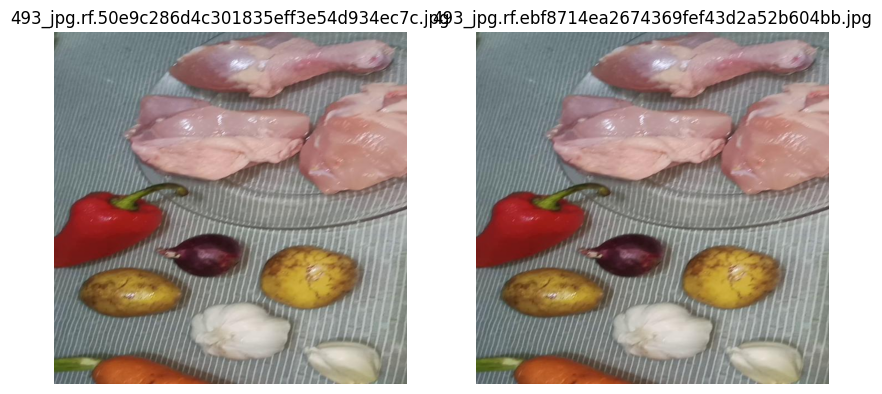

In [11]:
if len(duplicates) > 0:
    
    img1 = cv2.imread(os.path.join(TRAIN_IMG, duplicates[0][0]))
    img2 = cv2.imread(os.path.join(TRAIN_IMG, duplicates[0][1]))

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title(duplicates[0][0])
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title(duplicates[0][1])
    plt.axis("off")

    plt.show()

# 11. Copy dataset from kaggle input to working

In [12]:
SRC = "/kaggle/input/datasets/natashashrestha7/fingredient"
DEST = "/kaggle/working/fingredient"

shutil.copytree(SRC, DEST)

'/kaggle/working/fingredient'

In [13]:
IMG_DIR = DEST + "/train/images"
LBL_DIR = DEST + "/train/labels"

# 12. Remove duplicates (both image and label)

In [14]:
removed = 0

for dup, original in duplicates:
    
    img_path = os.path.join(IMG_DIR, dup)
    label_path = os.path.join(LBL_DIR, Path(dup).stem + ".txt")

    if os.path.exists(img_path):
        os.remove(img_path)

    if os.path.exists(label_path):
        os.remove(label_path)

    removed += 1

print("Removed:", removed)

Removed: 143


# 13. Load YOLO Model

In [15]:
model = YOLO("yolov8m.pt")

# 14. Train dataset with yolo model adding parameters

In [16]:
model.train(
    data=YAML_PATH,
    epochs=30,
    imgsz=640,
    batch=16,
    patience=20,
    optimizer="AdamW",
    lr0=0.001,
    project="/kaggle/working",
    name="flavorflow",
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0
)

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/natashashrestha7/fingredient/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=flavorflow, nbs=64, nms=False, opset=None, optimize=False, optimizer=A

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790aa7e96ab0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

# 15. Display metrics

In [17]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,851,340 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 86.6±24.3 MB/s, size: 43.6 KB)
val: Scanning /kaggle/input/datasets/natashashrestha7/fingredient/valid/labels... 2500 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2500/2500 679.6it/s 3.7s0.1s
val: /kaggle/input/datasets/natashashrestha7/fingredient/valid/images/photo-1590848791238-fb3596a2ba56_jpg.rf.97540ca3e6be651652e86a63edb353a3.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/natashashrestha7/fingredient/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 375, len(boxes) = 18377. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
             

# 16. Load training results csv

In [19]:
results = pd.read_csv("/kaggle/working/flavorflow/results.csv")
results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,463.234,1.35519,1.26568,1.50722,0.59985,0.57216,0.58480,0.33262,1.53620,1.82053,1.76272,0.000333,0.000333,0.067041
1,2,924.743,1.28796,1.05214,1.47180,0.72323,0.59617,0.63029,0.37238,1.44878,1.64483,1.69876,0.000644,0.000644,0.034019
2,3,1384.870,1.25901,0.97050,1.45873,0.64348,0.63892,0.64409,0.38665,1.41092,1.35161,1.62710,0.000934,0.000934,0.000975
3,4,1844.320,1.20814,0.88774,1.41685,0.74970,0.72427,0.75311,0.46641,1.30778,1.09012,1.55393,0.000901,0.000901,0.000901
4,5,2303.010,1.18091,0.82953,1.40215,0.82115,0.75793,0.79460,0.51818,1.20928,0.95385,1.49238,0.000868,0.000868,0.000868


# 17. Plot loss curve

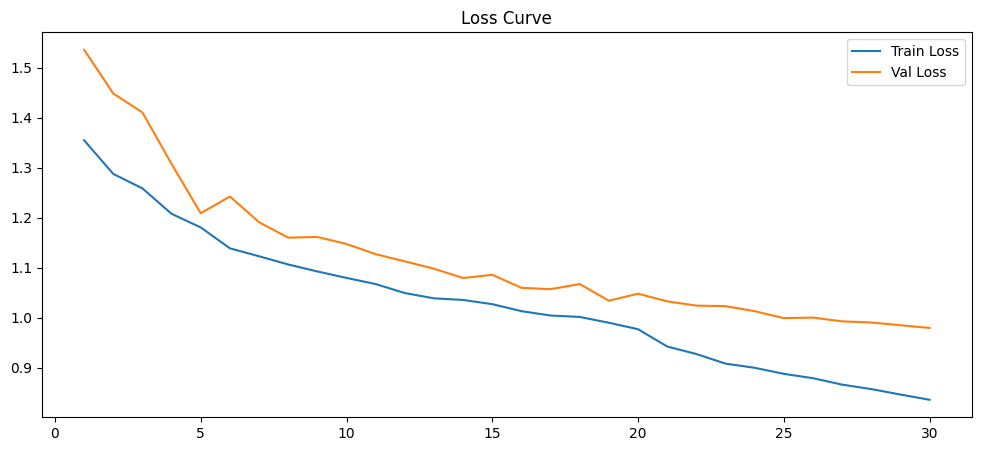

In [20]:
plt.figure(figsize=(12,5))

plt.plot(results["epoch"], results["train/box_loss"], label="Train Loss")
plt.plot(results["epoch"], results["val/box_loss"], label="Val Loss")

plt.legend()
plt.title("Loss Curve")
plt.show()

# 18. Plot accuracy curve

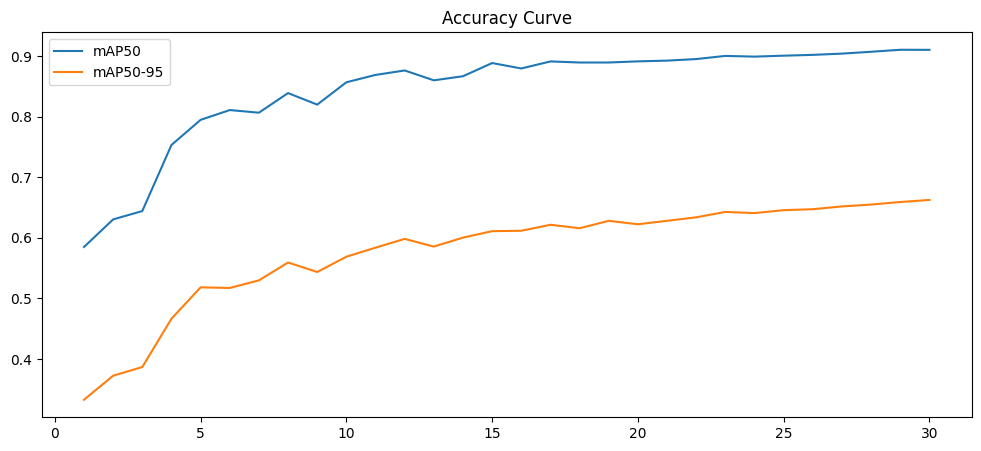

In [21]:
plt.figure(figsize=(12,5))

plt.plot(results["epoch"], results["metrics/mAP50(B)"], label="mAP50")
plt.plot(results["epoch"], results["metrics/mAP50-95(B)"], label="mAP50-95")

plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [12]:
source_dir = "/kaggle/input/datasets/natashashrestha7/models"

shutil.copy(f"{source_dir}/best.pt", "/kaggle/working/best.pt")
shutil.copy(f"{source_dir}/last.pt", "/kaggle/working/last.pt")

print("Files copied successfully!")

Files copied successfully!


# 19. Load best model

In [13]:
best_model = YOLO("/kaggle/working/best.pt")

# 20. Predict on random image

In [22]:
test_imgs = list(Path(DATASET_PATH + "/test/images").glob("*.*"))

img = random.choice(test_imgs)

result = best_model.predict(
    source=str(img),
    conf=0.25,
    save=False
)


image 1/1 /kaggle/input/datasets/natashashrestha7/fingredient/test/images/1647_jpg.rf.94b06b053c6928bd8849e8c60450e868.jpg: 640x640 1 bell_pepper, 2 garlics, 2 onions, 2 tomatos, 37.0ms
Speed: 1.9ms preprocess, 37.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


# 21. Visualise bounding boxes

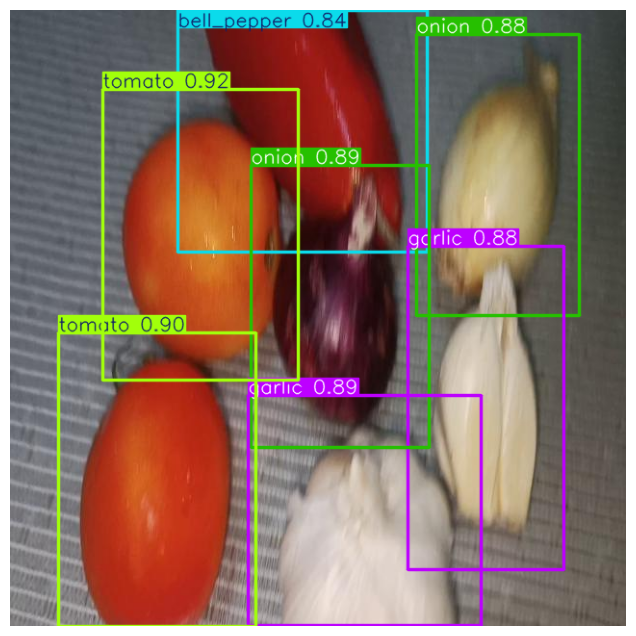

In [23]:
annotated = result[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.show()

# 22. Print detected ingredients

In [28]:
names = best_model.names
classes = result[0].boxes.cls.cpu().numpy()

ingredients = []

for c in classes:
    ingredients.append(names[int(c)])

ingredients = list((ingredients))

print("Detected:", ingredients)

Detected: ['tomato', 'tomato', 'garlic', 'onion', 'garlic', 'onion', 'bell_pepper']


In [27]:
source_folder = "/kaggle/working/flavorflow/weights"

# Output zip file
output_zip = "/kaggle/working/weights_backup"

# Create zip
shutil.make_archive(output_zip, 'zip', source_folder)

print("weights folder zipped successfully!")
print("Saved as: /kaggle/working/weights_backup.zip")

weights folder zipped successfully!
Saved as: /kaggle/working/weights_backup.zip


# 23. Count detected ingredients

In [29]:
counts = Counter(ingredients)

print("\n🍽️ Detected Ingredients with Counts:\n")

for ingredient, count in counts.items():
    print(f"{ingredient} → {count}")


🍽️ Detected Ingredients with Counts:

tomato → 2
garlic → 2
onion → 2
bell_pepper → 1


In [32]:
ingredient_data = dict(counts)

print(ingredient_data)

{'tomato': 2, 'garlic': 2, 'onion': 2, 'bell_pepper': 1}


# 24. Fine tuning yolo model

In [34]:
model = YOLO("/kaggle/working/last.pt")

model.train(
    data=YAML_PATH,

    epochs=60,

    imgsz=640,
    batch=16,

    optimizer="AdamW",

    # FINE-TUNING CHANGE
    lr0=0.0003,      # lower learning rate 

    project="/kaggle/working",
    name="flavorflow_finetune_v2",

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    
    mosaic=1.0,

    resume=False   
)

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/natashashrestha7/fingredient/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=flavorflow_finetune_v2, nbs=64, nms=False, opset=None, optim

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f76c4e9ca0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

# 25. Display metrics

In [35]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,851,340 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 72.6±52.2 MB/s, size: 63.6 KB)
val: Scanning /kaggle/input/datasets/natashashrestha7/fingredient/valid/labels... 2500 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2500/2500 471.4it/s 5.3s0.1s
val: /kaggle/input/datasets/natashashrestha7/fingredient/valid/images/photo-1590848791238-fb3596a2ba56_jpg.rf.97540ca3e6be651652e86a63edb353a3.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/natashashrestha7/fingredient/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 375, len(boxes) = 18377. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
             

In [36]:
source_folder = "/kaggle/working/flavorflow_finetune_v2/weights"

# Output zip file
output_zip = "/kaggle/working/finetune_backup"

# Create zip
shutil.make_archive(output_zip, 'zip', source_folder)

print("weights folder zipped successfully!")
print("Saved as: /kaggle/working/finetune_backup.zip")

weights folder zipped successfully!
Saved as: /kaggle/working/finetune_backup.zip


# 26. Load training result csv

In [37]:
results = pd.read_csv("/kaggle/working/flavorflow_finetune_v2/results.csv")
results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,506.492,0.99021,0.57128,1.26961,0.86067,0.81920,0.88643,0.61557,1.07931,0.67099,1.38549,0.000100,0.000100,0.066808
1,2,1006.530,0.95212,0.52714,1.24140,0.88362,0.86821,0.90068,0.63651,1.02893,0.61472,1.34369,0.000197,0.000197,0.033571
2,3,1504.270,0.94634,0.51619,1.23807,0.89528,0.86330,0.90581,0.64286,1.01827,0.59016,1.31205,0.000290,0.000290,0.000331
3,4,2001.940,0.93381,0.51089,1.23034,0.87655,0.87666,0.90237,0.64325,1.00363,0.59601,1.31848,0.000285,0.000285,0.000285
4,5,2499.500,0.93116,0.50486,1.23168,0.88266,0.86775,0.90932,0.65045,1.00531,0.58337,1.30527,0.000280,0.000280,0.000280


# 27. Final metric

In [78]:
last_row = results.iloc[-1]

print("Final Metrics:\n")
print("Precision :", round(last_row["metrics/precision(B)"],3))
print("Recall    :", round(last_row["metrics/recall(B)"],3))
print("mAP50     :", round(last_row["metrics/mAP50(B)"],3))
print("mAP50-95  :", round(last_row["metrics/mAP50-95(B)"],3))

Final Metrics:

Precision : 0.922
Recall    : 0.888
mAP50     : 0.926
mAP50-95  : 0.693


# 28. Plot loss curve

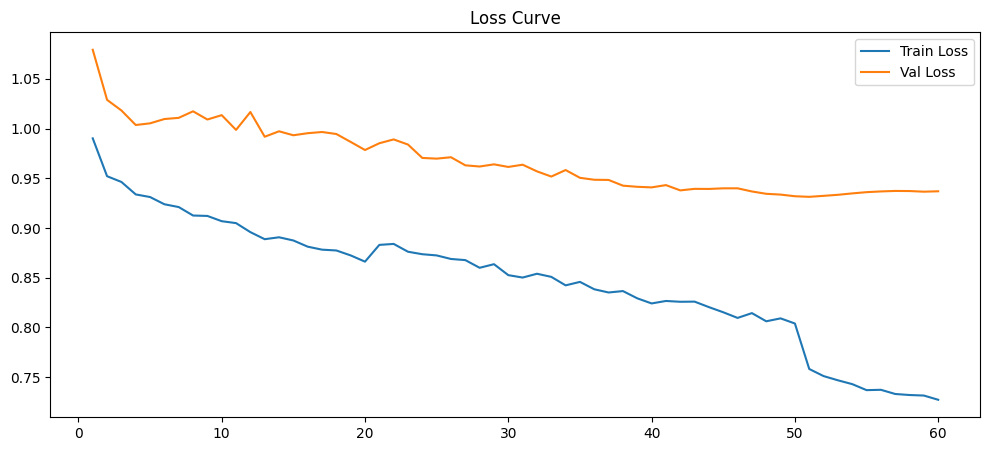

In [38]:
plt.figure(figsize=(12,5))

plt.plot(results["epoch"], results["train/box_loss"], label="Train Loss")
plt.plot(results["epoch"], results["val/box_loss"], label="Val Loss")

plt.legend()
plt.title("Loss Curve")
plt.show()

# 29. Plot accuracy curve

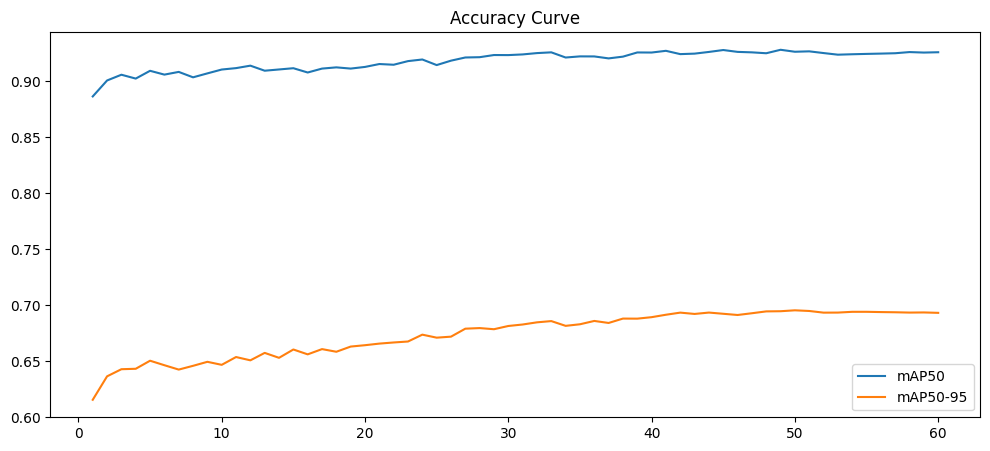

In [39]:
plt.figure(figsize=(12,5))

plt.plot(results["epoch"], results["metrics/mAP50(B)"], label="mAP50")
plt.plot(results["epoch"], results["metrics/mAP50-95(B)"], label="mAP50-95")

plt.legend()
plt.title("Accuracy Curve")
plt.show()

# 30. Load fine tuned model

In [40]:
best_model = YOLO("/kaggle/working/flavorflow_finetune_v2/weights/best.pt")

# 31. Load random image from test set and predict

In [80]:
test_imgs = list(Path(DATASET_PATH + "/test/images").glob("*.*"))

img = random.choice(test_imgs)

result = best_model.predict(
    source=str(img),
    conf=0.25,
    save=False
)


image 1/1 /kaggle/input/datasets/natashashrestha7/fingredient/test/images/314_jpg.rf.b27fe76a94559b81735057958cd4156f.jpg: 640x640 3 chickens, 1 garlic, 2 onions, 2 potatos, 38.0ms
Speed: 1.9ms preprocess, 38.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


# 32. Annotate the detected ingredients

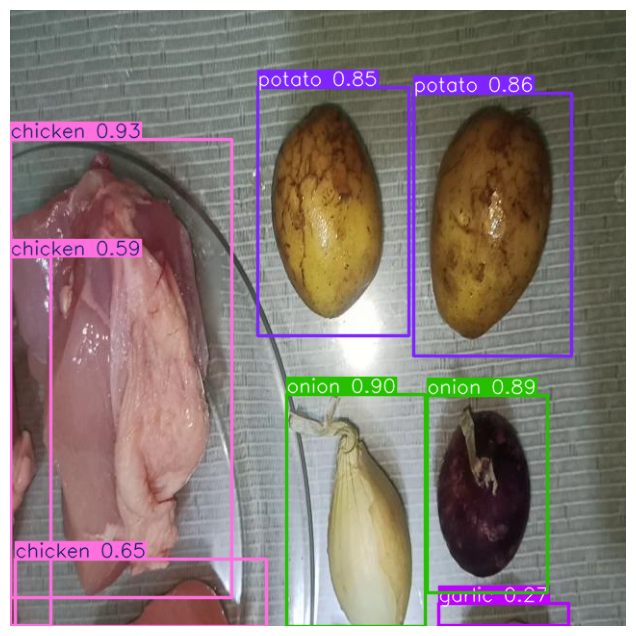

In [81]:
annotated = result[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.show()

# 33. Print detected ingredients

In [82]:
names = best_model.names
classes = result[0].boxes.cls.cpu().numpy()

ingredients = []

for c in classes:
    ingredients.append(names[int(c)])

ingredients = list((ingredients))

print("Detected:", ingredients)

Detected: ['chicken', 'onion', 'onion', 'potato', 'potato', 'chicken', 'chicken', 'garlic']


# 34. Count each ingredients

In [83]:
counts = Counter(ingredients)

print("\n🍽️ Detected Ingredients with Counts:\n")

for ingredient, count in counts.items():
    print(f"{ingredient} → {count}")


🍽️ Detected Ingredients with Counts:

chicken → 3
onion → 2
potato → 2
garlic → 1


# 35. Confidence score

In [87]:
confs = result[0].boxes.conf.cpu().numpy()

print("\nConfidence Scores:\n")

for i in range(len(ingredients)):
    print(f"{ingredients[i]} : {round(confs[i]*100,2)}%")


Confidence Scores:

chicken : 92.56999969482422%
onion : 90.37000274658203%
onion : 88.62000274658203%
potato : 86.33000183105469%
potato : 84.86000061035156%
chicken : 64.83000183105469%
chicken : 59.369998931884766%
garlic : 27.110000610351562%


In [46]:
ingredient_data = dict(counts)

print(ingredient_data)

{'ginger': 2, 'onion': 5, 'tomato': 5}


# 36. Import image from web

(np.float64(-0.5), np.float64(739.5), np.float64(492.5), np.float64(-0.5))

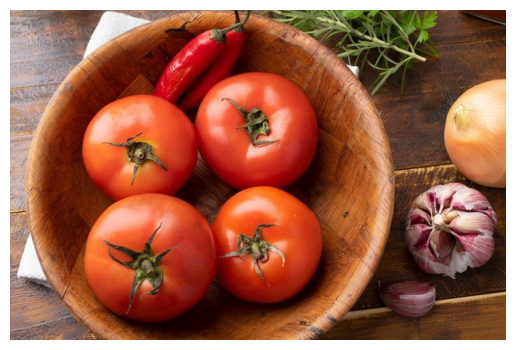

In [73]:
url = "https://imgs.search.brave.com/-UGHbYoRiIcjf86yC4Iy8LwOZbrWInKDbTOwOUSBgMs/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9pbWcu/ZnJlZXBpay5jb20v/cHJlbWl1bS1waG90/by90b21hdG9lcy1n/YXJsaWMtcGVwcGVy/cy1oZXJicy13b29k/LXRhYmxlXzkyNTM0/LTUzOS5qcGc_c2Vt/dD1haXNfaHlicmlk/Jnc9NzQw"

response = requests.get(url)
img = Image.open(BytesIO(response.content))

plt.imshow(img)
plt.axis('off')

# 37. Predict on imported image

In [74]:
result = best_model.predict(
    source=img,     
    conf=0.25,
    save=False
)


0: 448x640 3 garlics, 4 tomatos, 28.3ms
Speed: 2.8ms preprocess, 28.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


# 38. Annotate the image

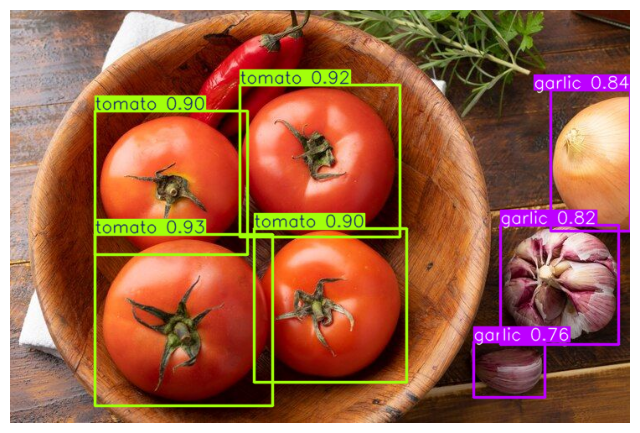

In [75]:
annotated = result[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.show()

In [72]:
source_folder = "/kaggle/working/flavorflow_finetune_v2"

# Output zip file
output_zip = "/kaggle/working/finetune_model"

# Create zip
shutil.make_archive(output_zip, 'zip', source_folder)

print("weights folder zipped successfully!")
print("Saved as: /kaggle/working/finetune_model.zip")

weights folder zipped successfully!
Saved as: /kaggle/working/finetune_model.zip
